<a href="https://colab.research.google.com/github/js-god/links/blob/main/Graph_RAG_with_Unstructured_and_AstraDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph RAG with Unstructured and AstraDB

Graph RAG is an enhancement to the retrieval-augmented generation (RAG) approach. It retrieves a knowledge graph as grounding context to provide to a large language model (LLM) for generation. Knowledge graphs can capture important connections in your documents that semantic embedding models miss.

In this demo, the Unstructured Platform plays a critical role in preparing document data for ingestion into the knowledge graph. Unstructured's robust parsing and data extraction capabilities allow it to process diverse document formats—such as PDFs, HTML, or plain text—and produce structured outputs that preserve the semantic relationships within the content. This structured output is then used to construct edges for the knowledge graph, ensuring that the graph accurately reflects the key relationships found in the original documents.

AstraDB, a scalable database-as-a-service, serves as the storage backend for the knowledge graph. Its distributed architecture enables efficient querying of large-scale graph data, allowing for rapid retrieval of the relevant subgraphs used as context during the generation process. AstraDB's support for graph structures, combined with its high availability and performance, ensures that the retrieval phase of the RAG pipeline is both reliable and responsive. Together with Unstructured, AstraDB provides a robust foundation for transforming raw documents into actionable insights, enabling the LLM to generate more accurate and contextually grounded responses.


## Loading documents into AstraDB with the Unstructured Platform

The Unstructured Platform makes it easy to load, extract, chunk and embed your documents. Connect to you documents wherever they're stored and instantly populate your AstraDB Graph Vector store.

Start by creating a data source so Unstructured can access your documents

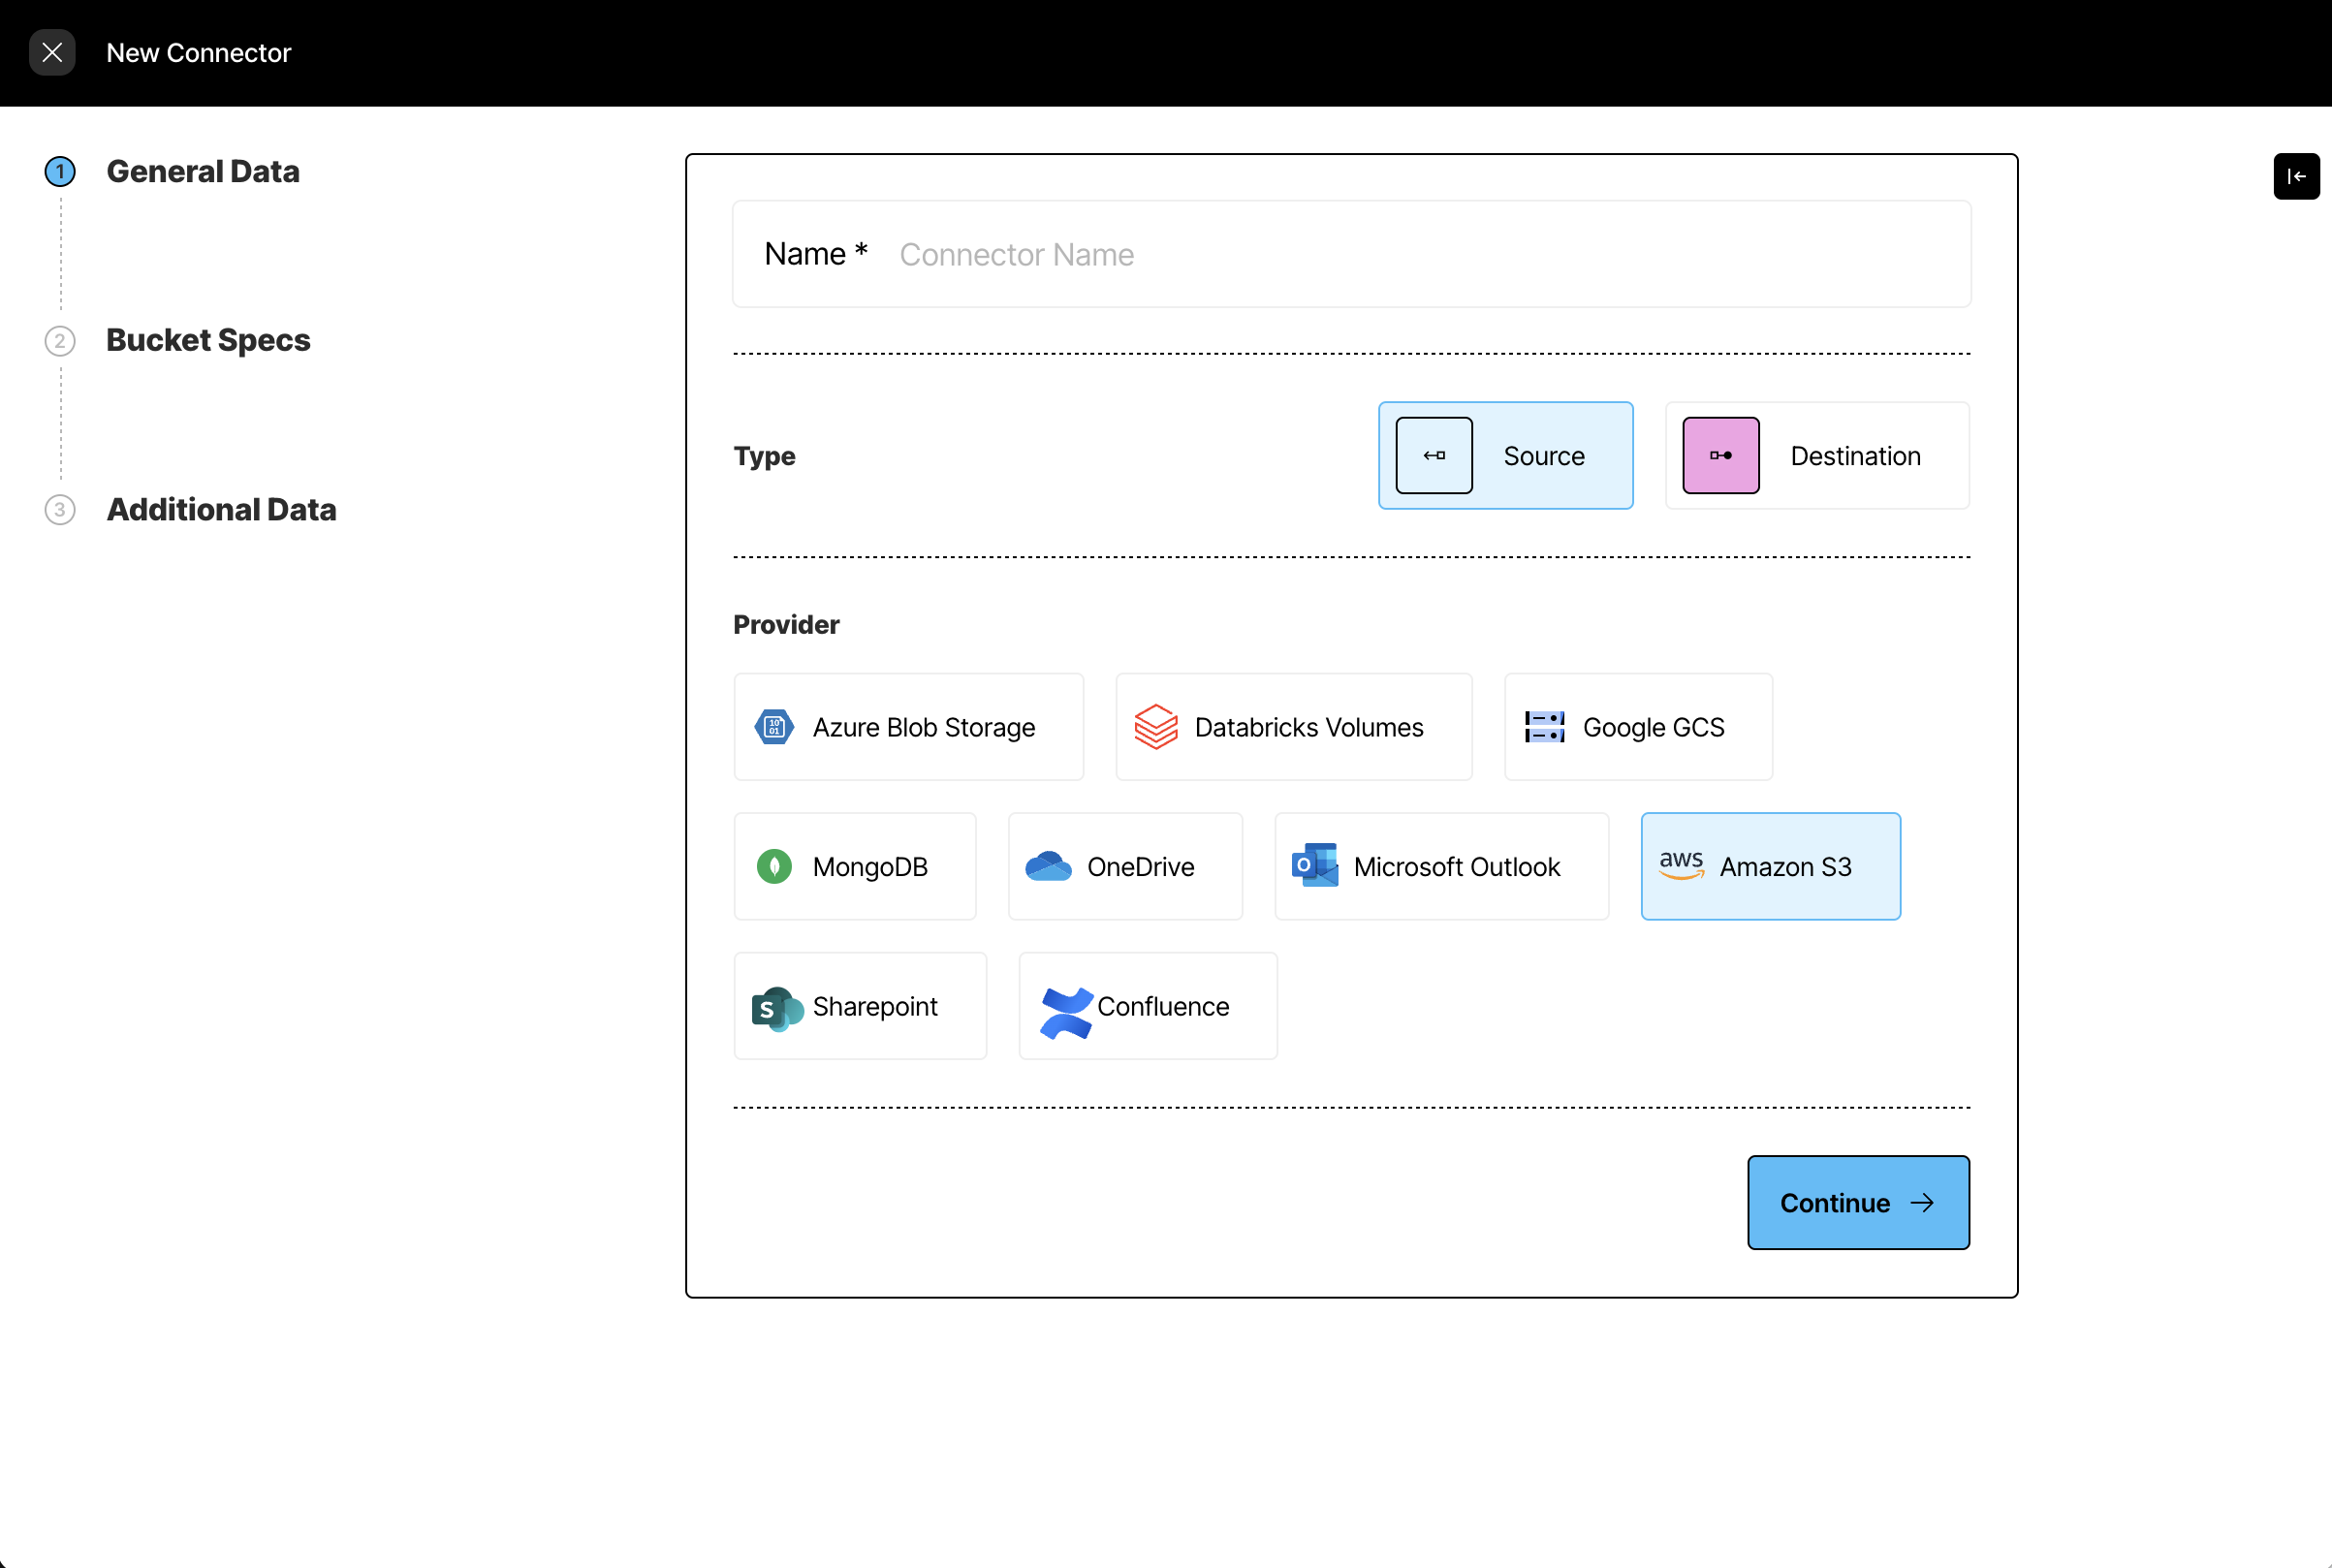

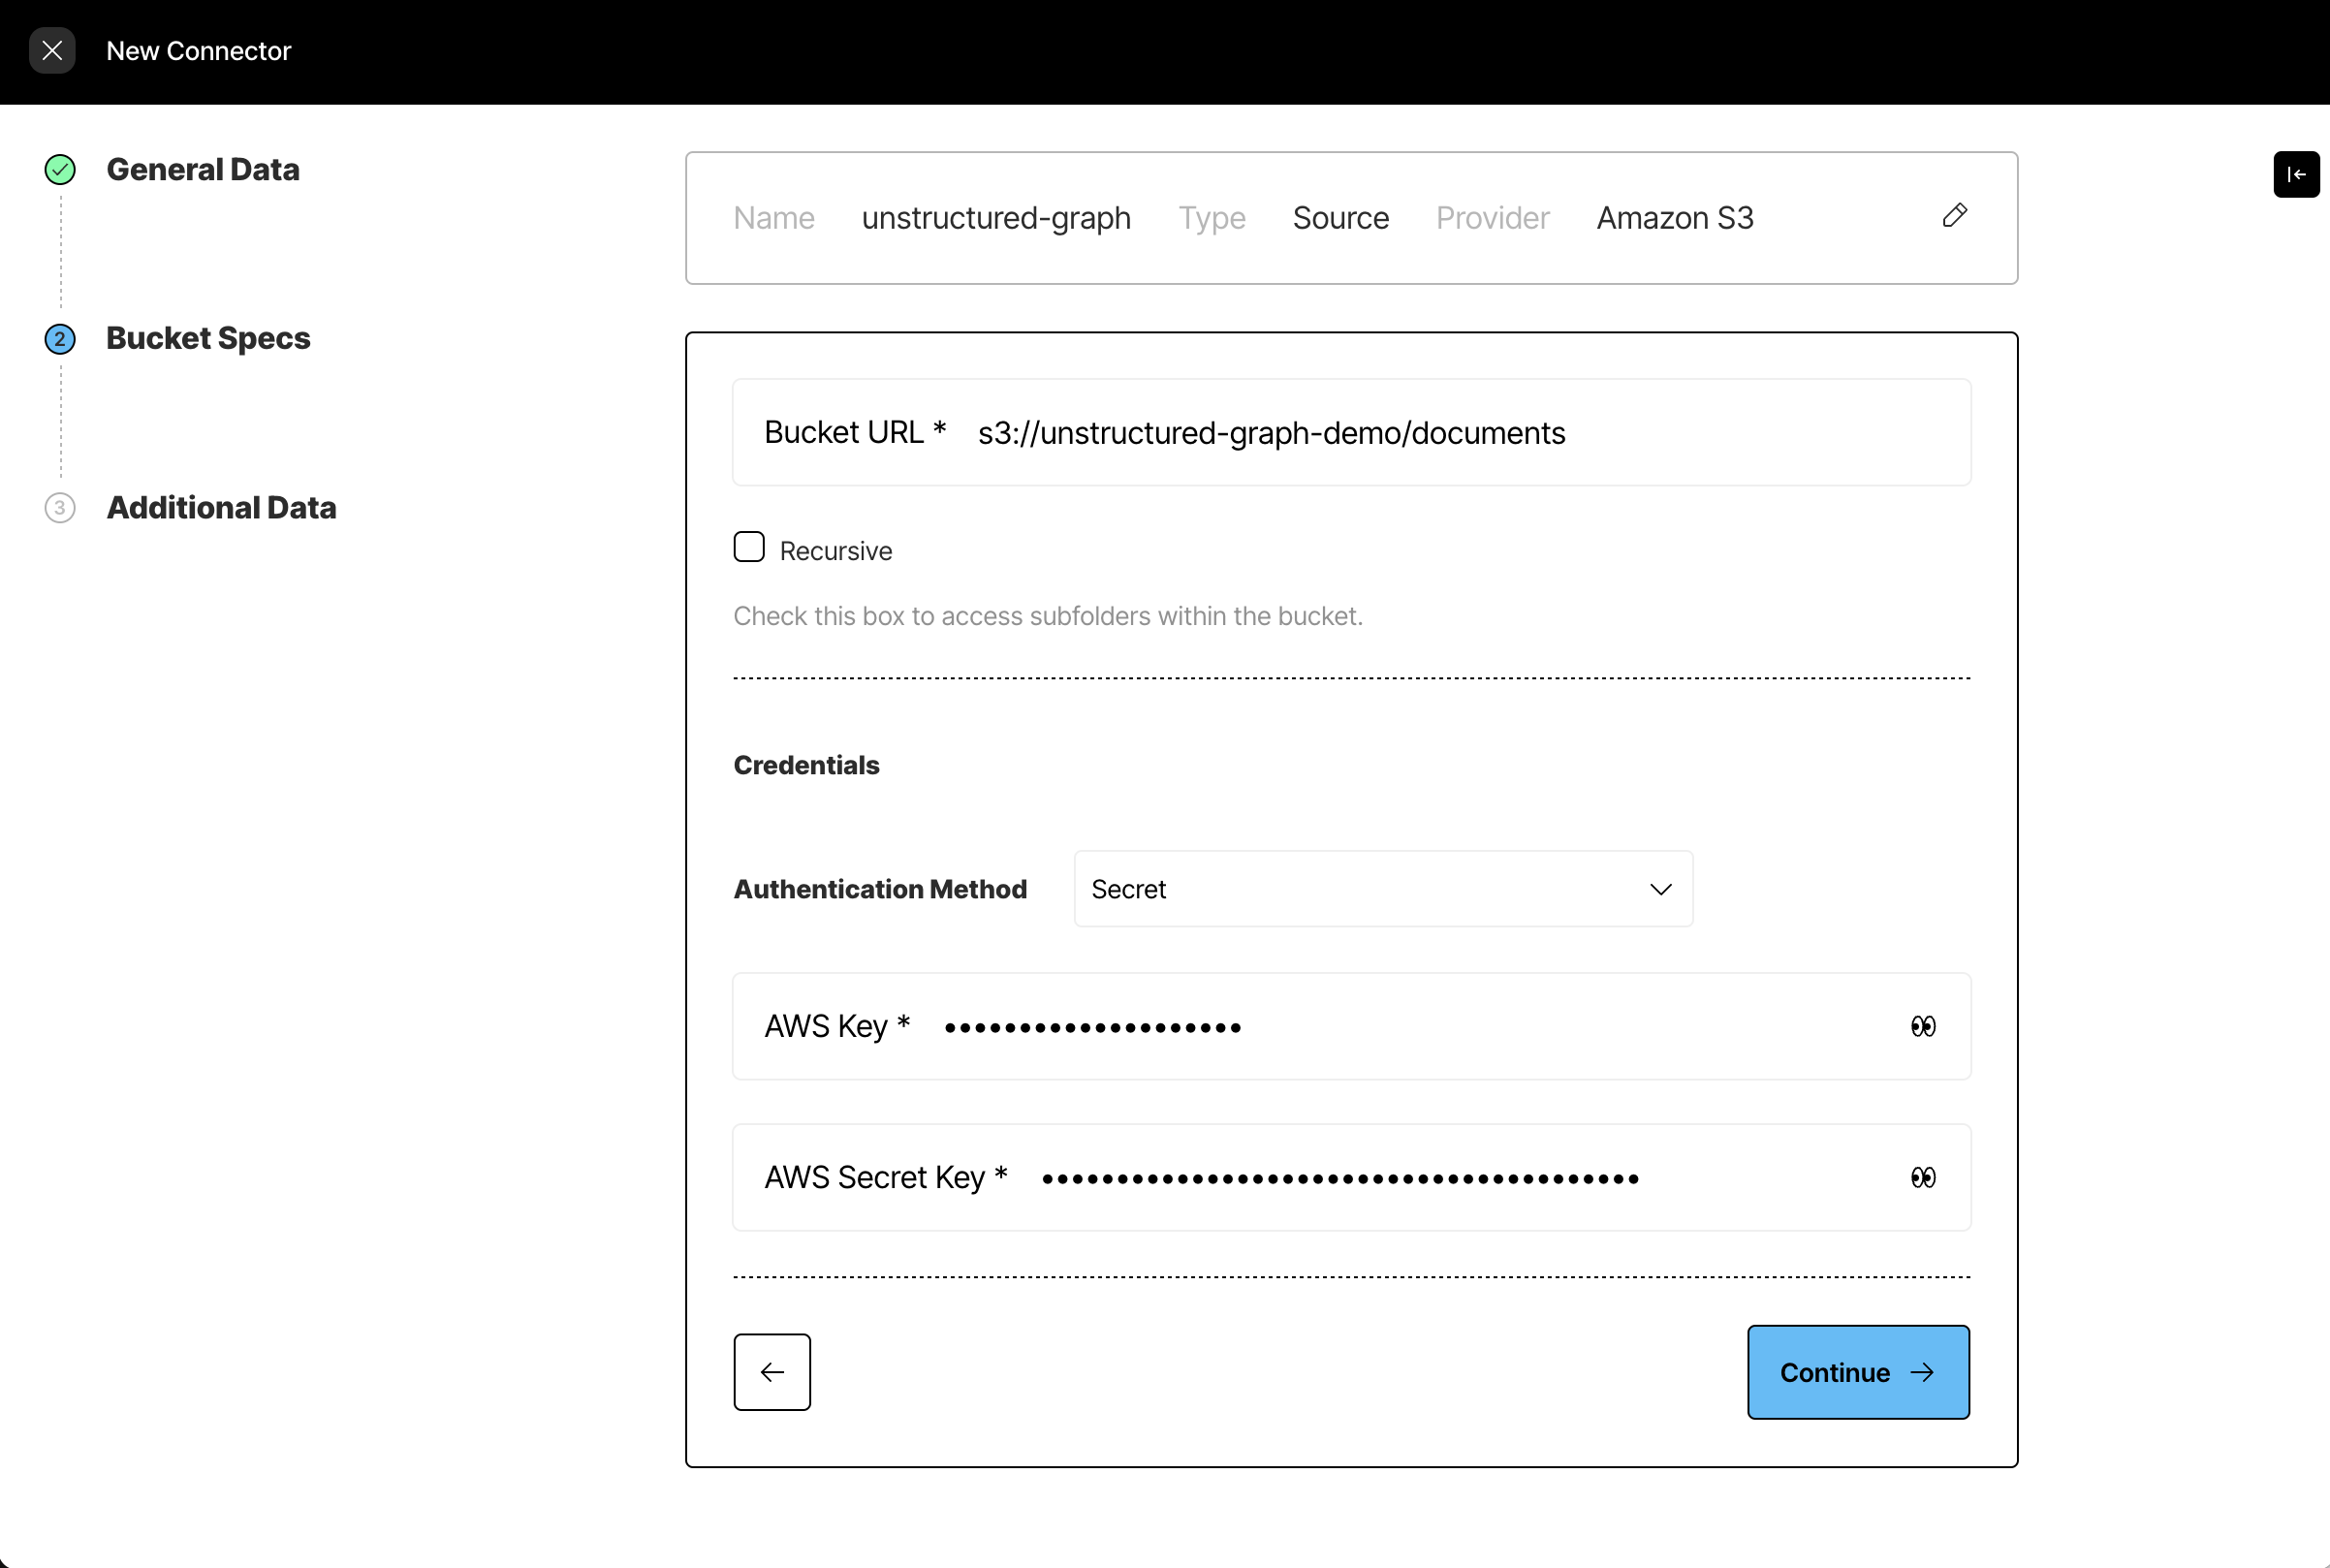

Next, connect Unstructured to your vector-enabled AstraDB collection.

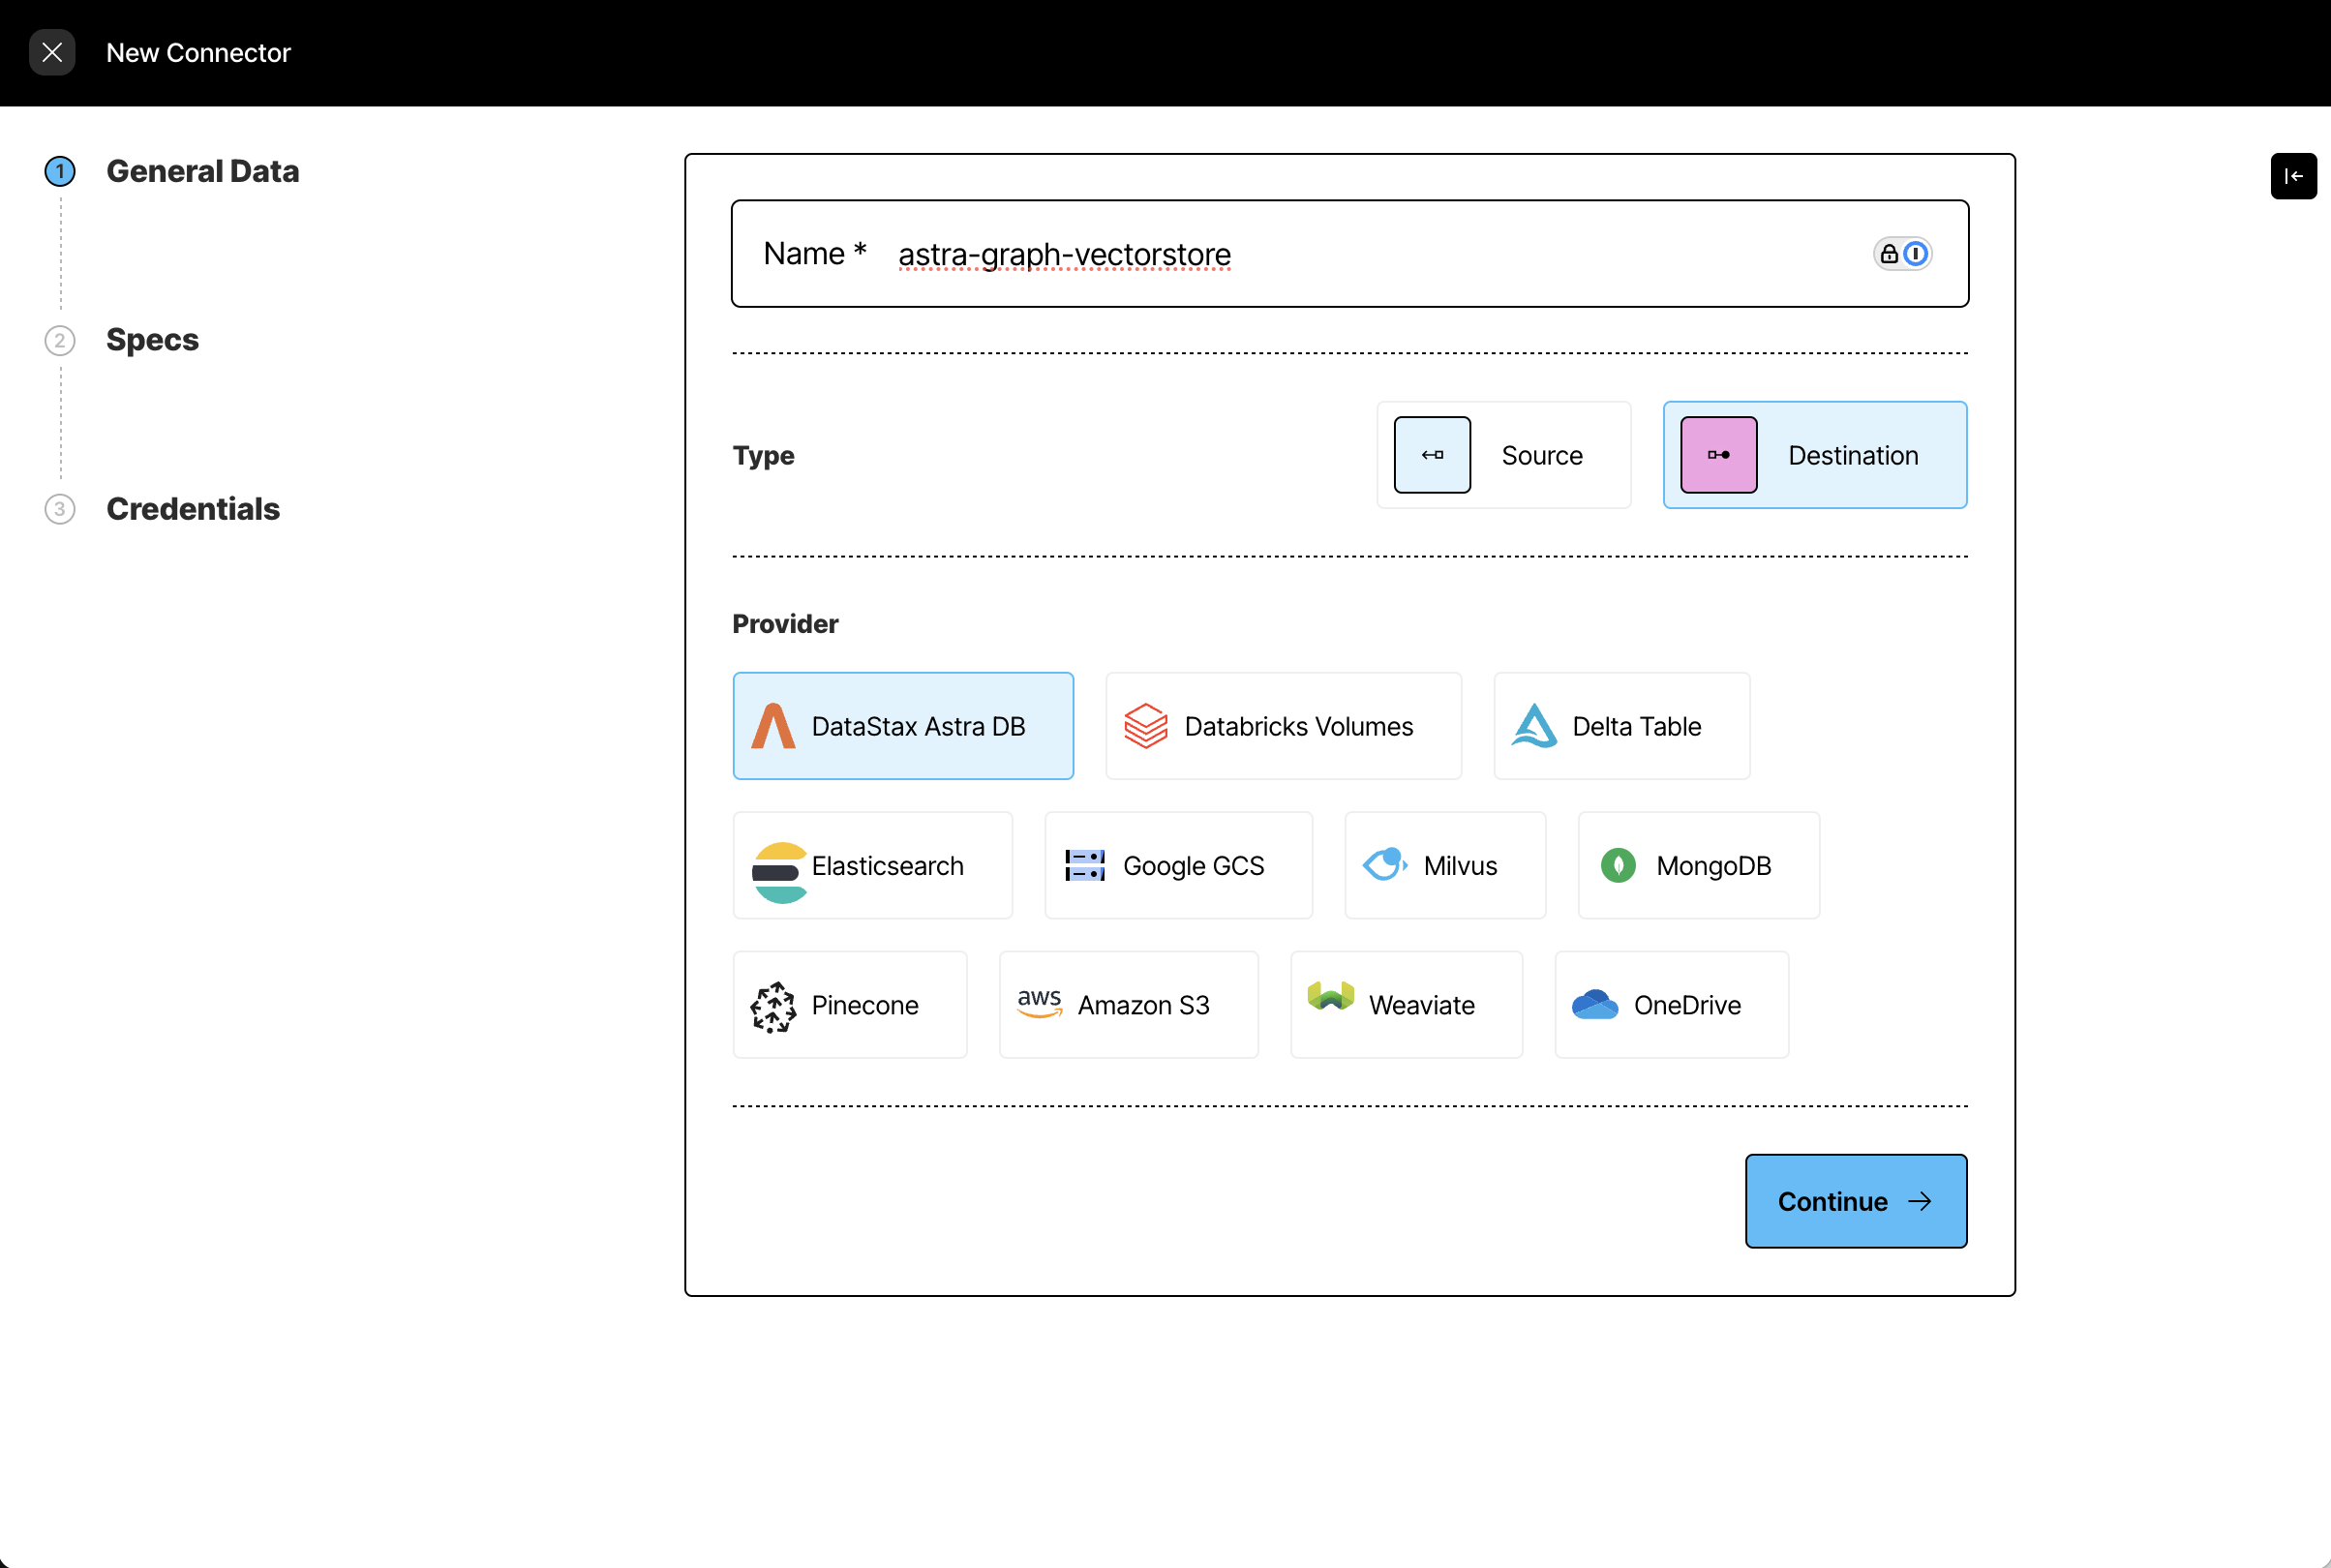

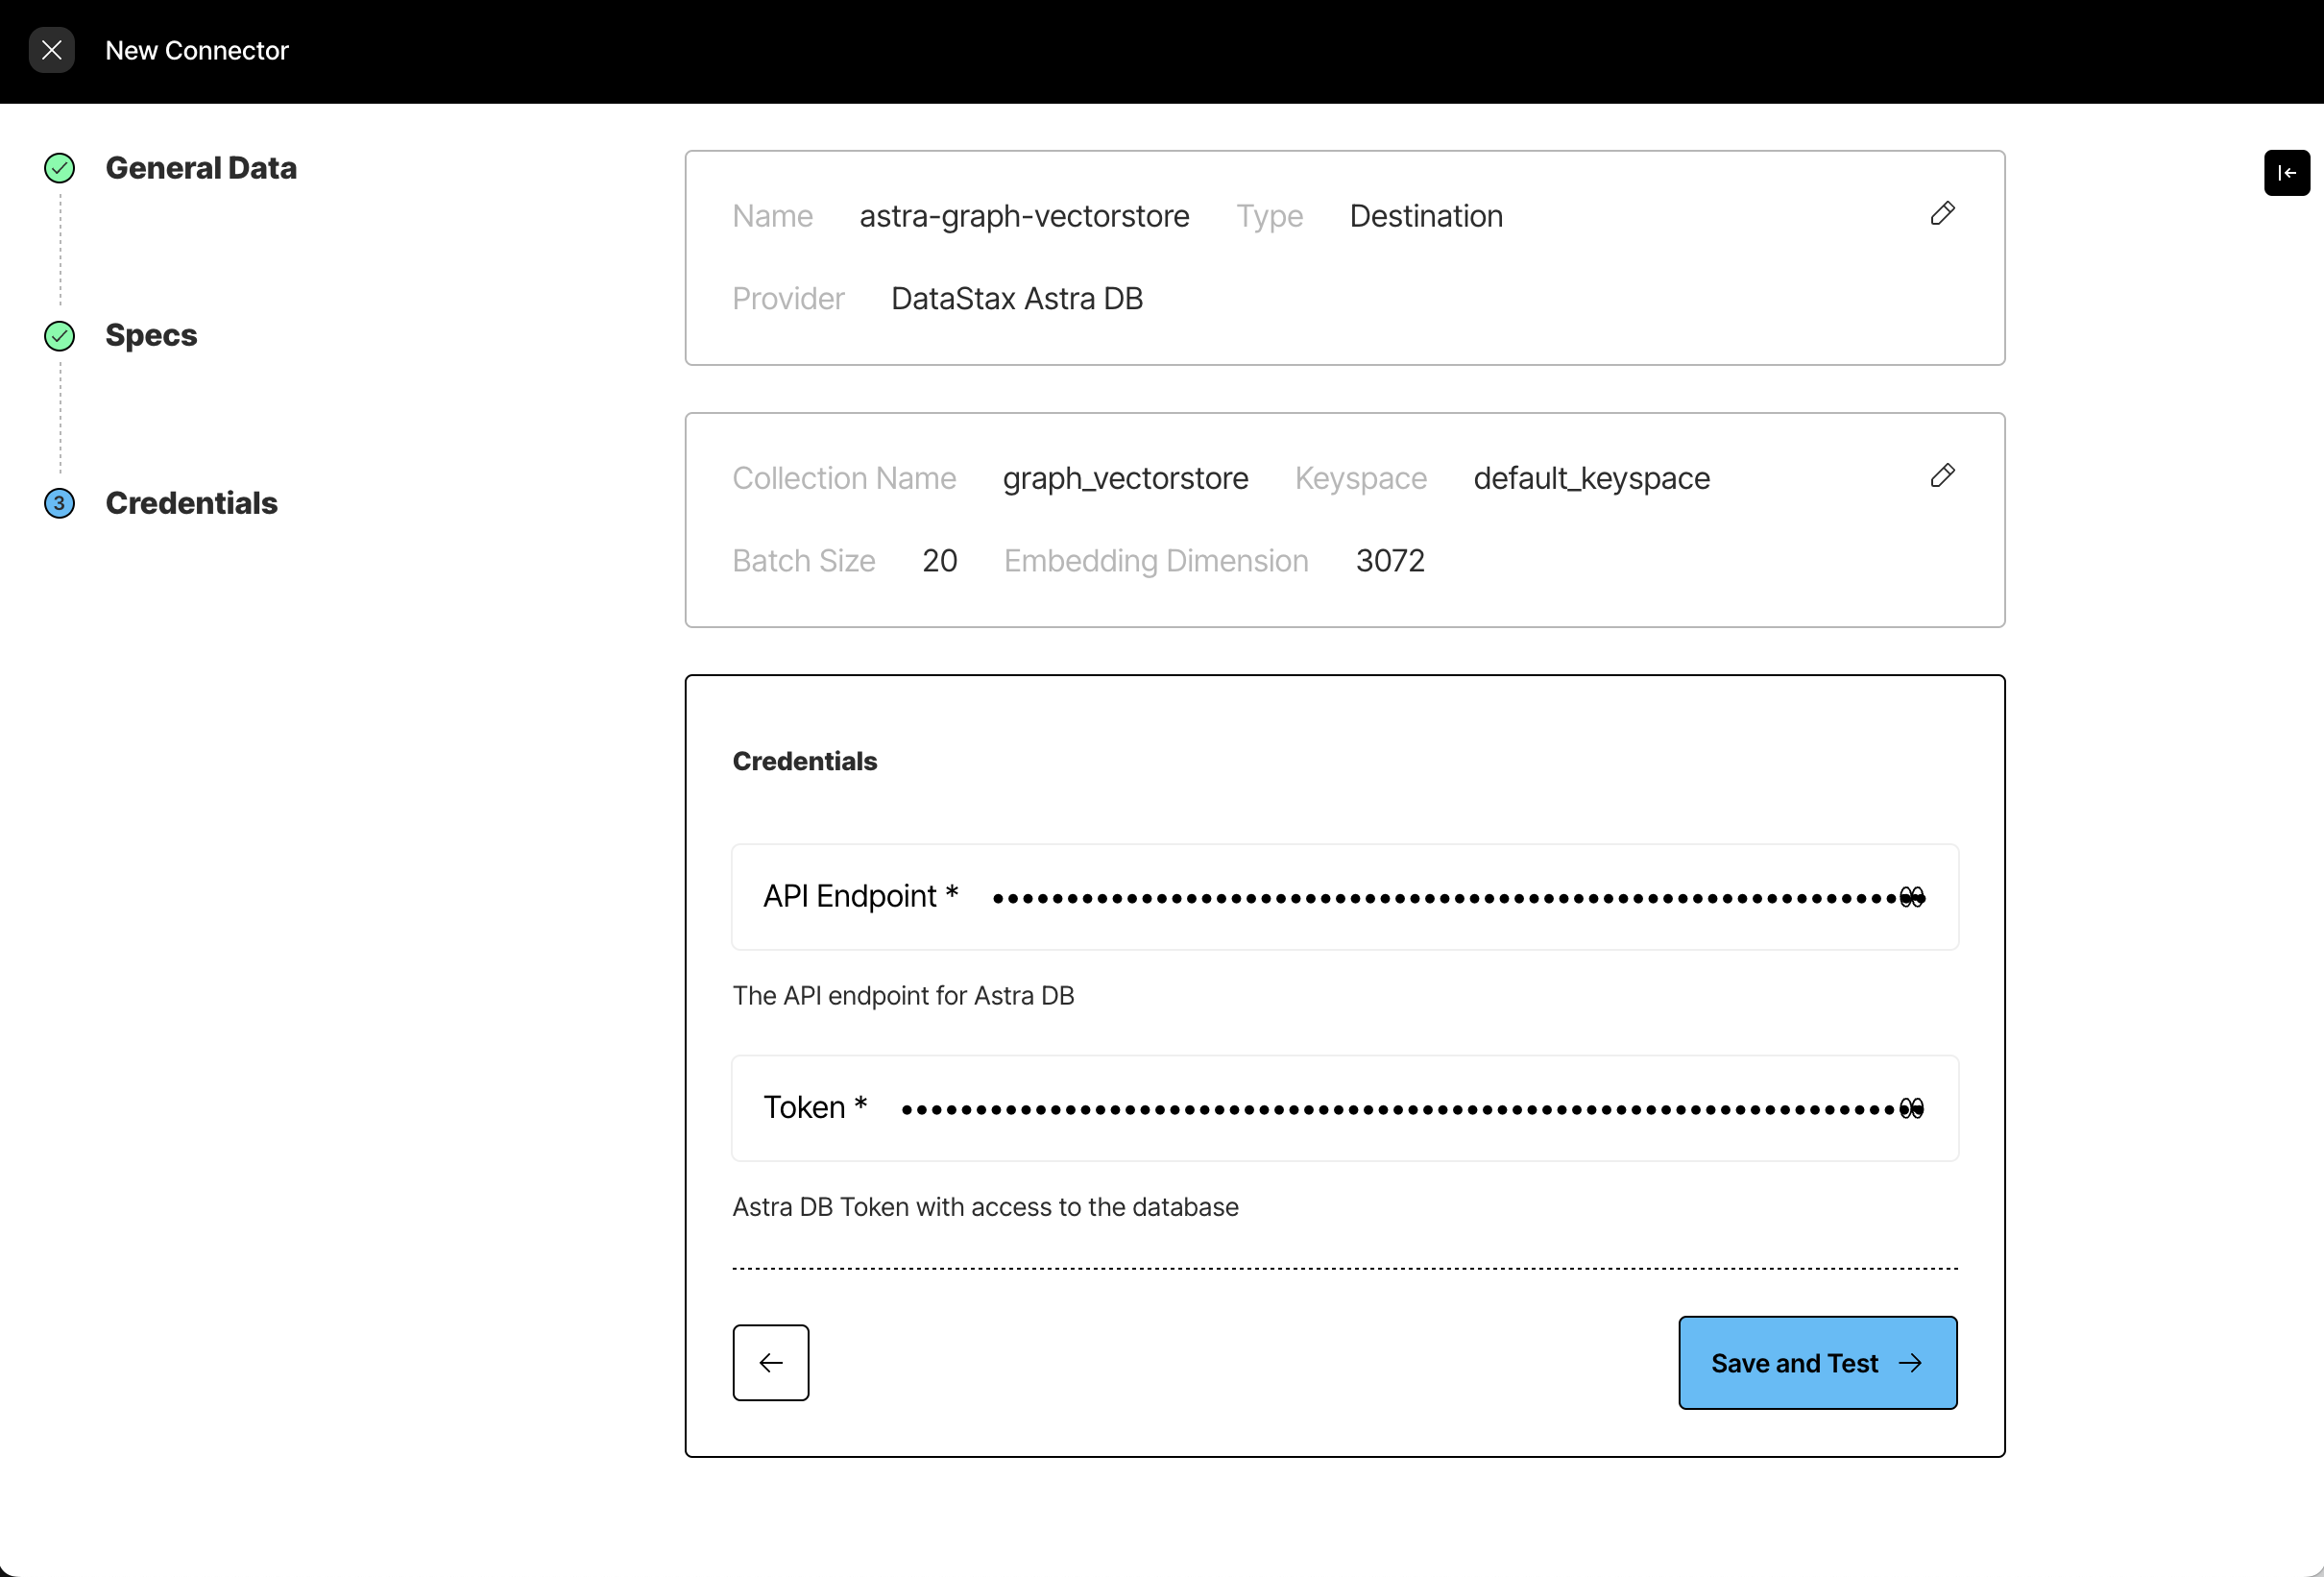

Configure a document processing pipeline.

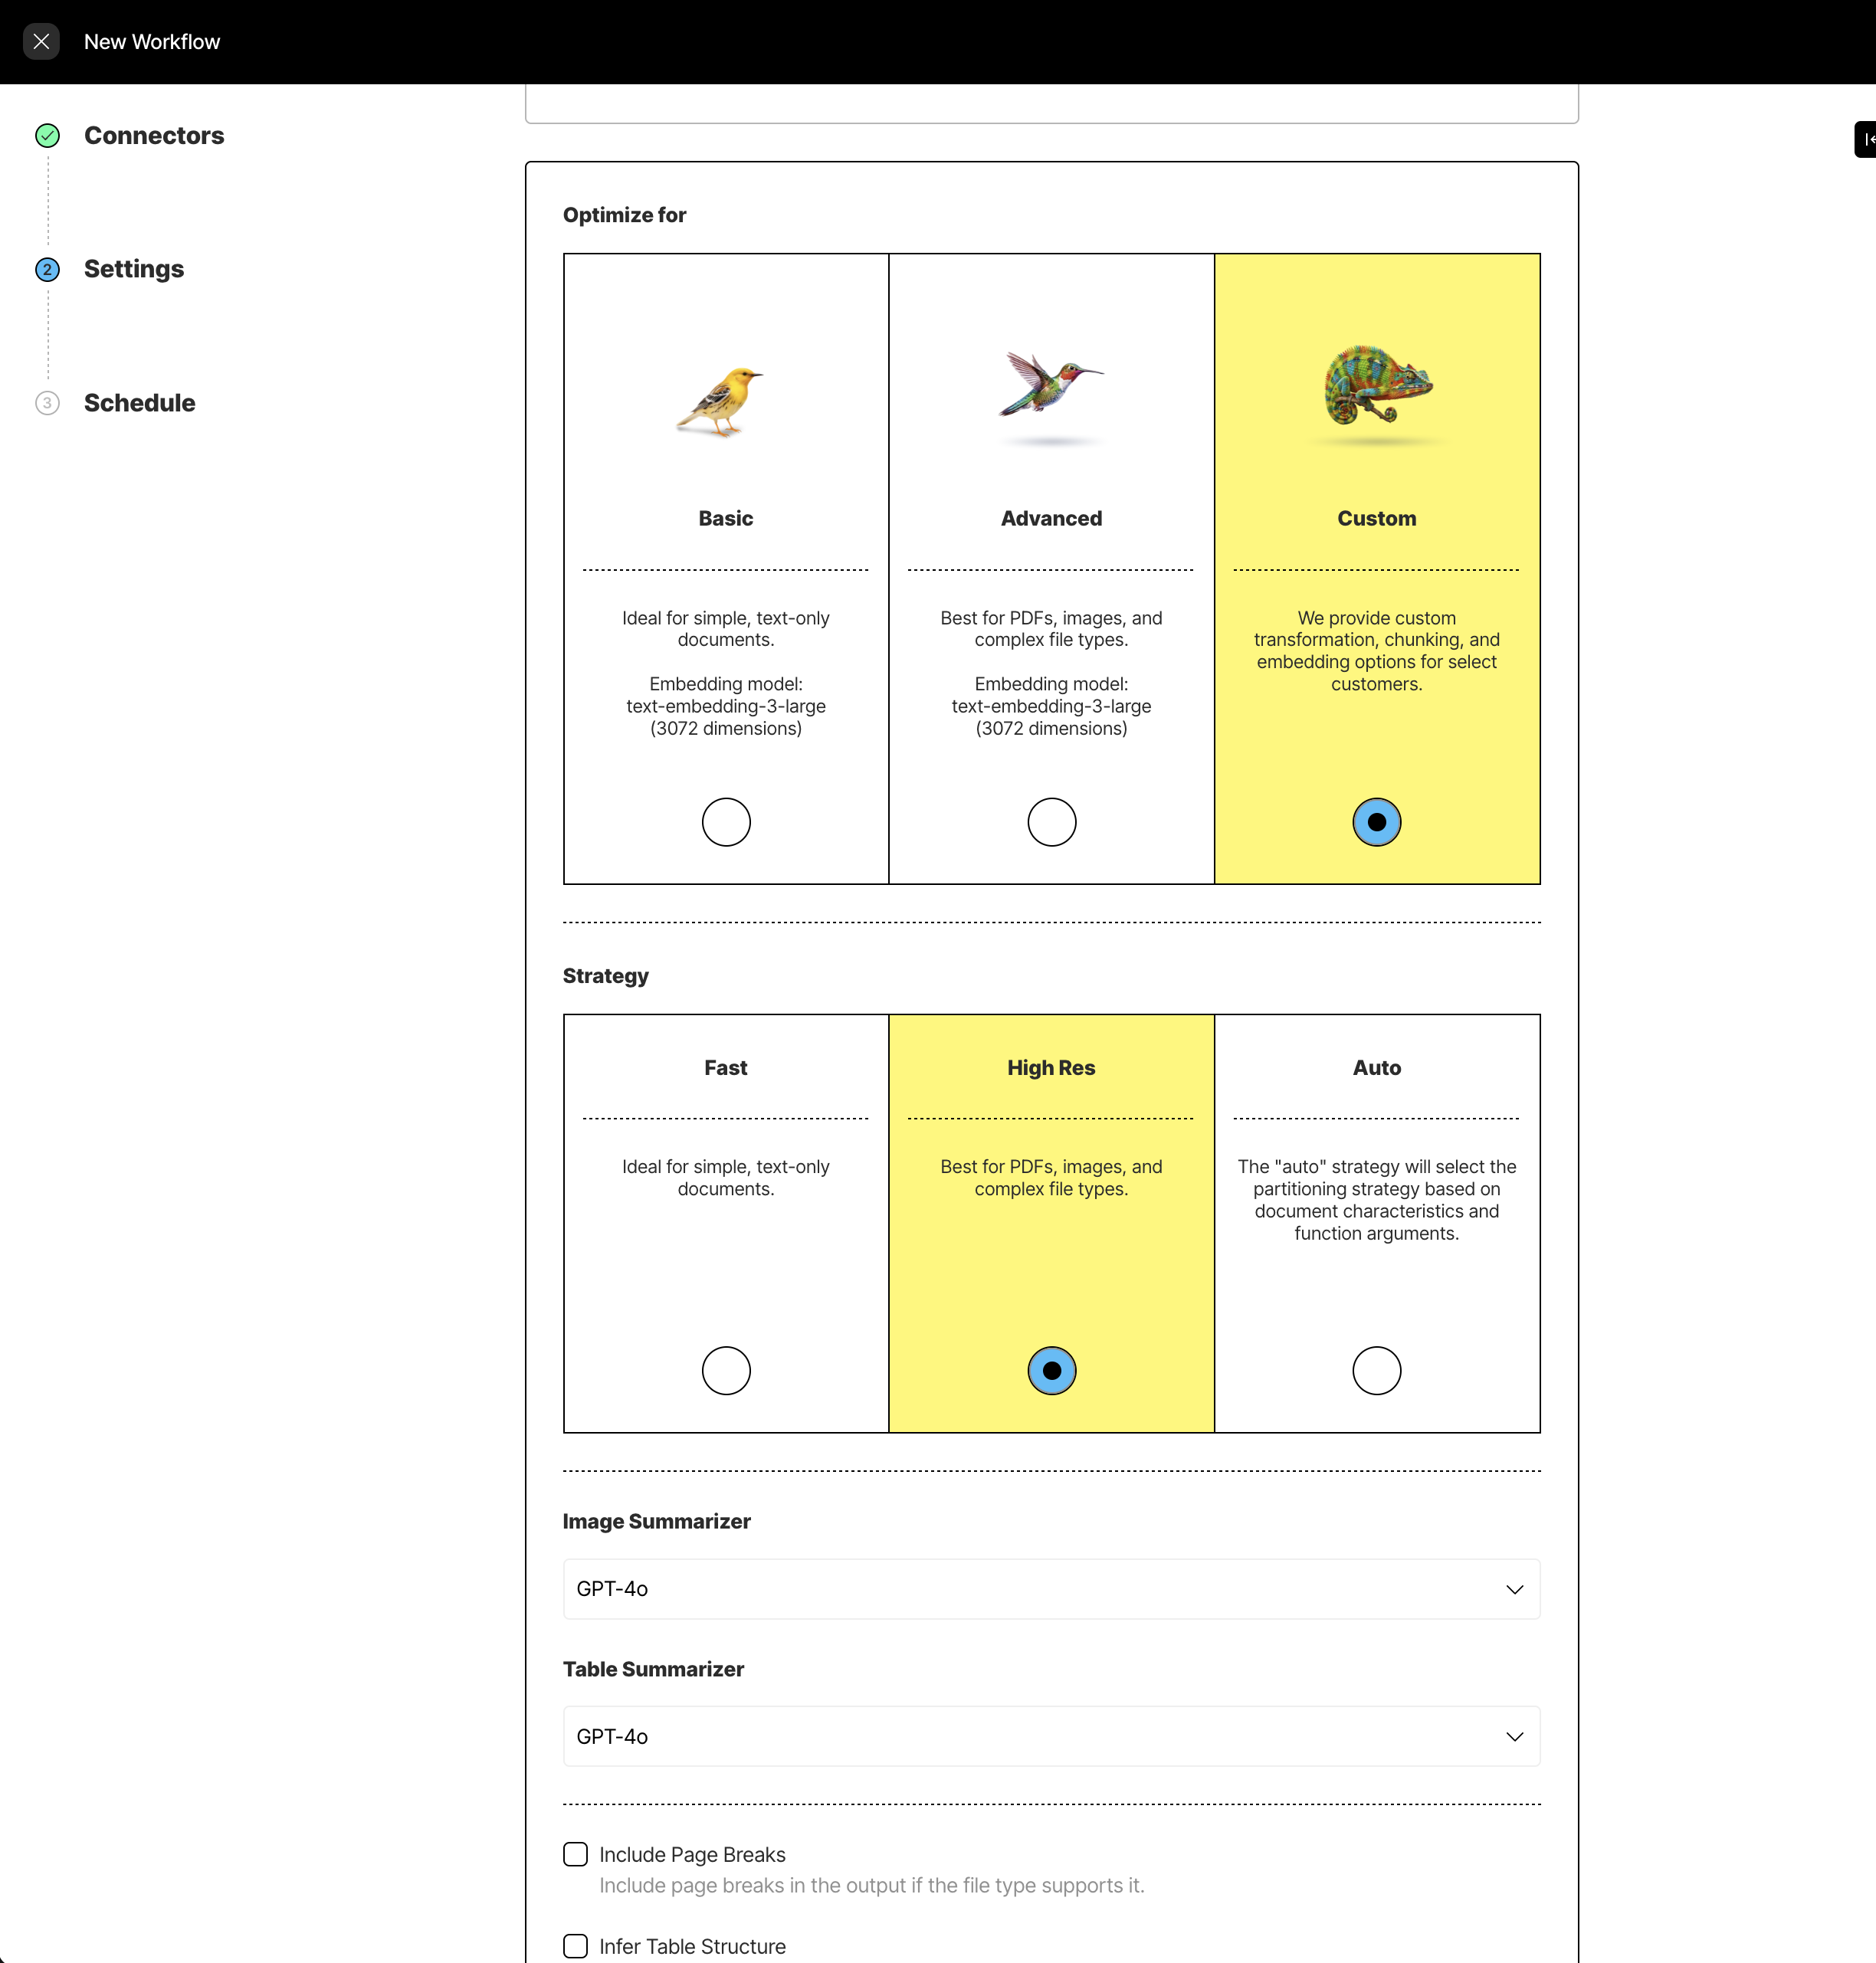

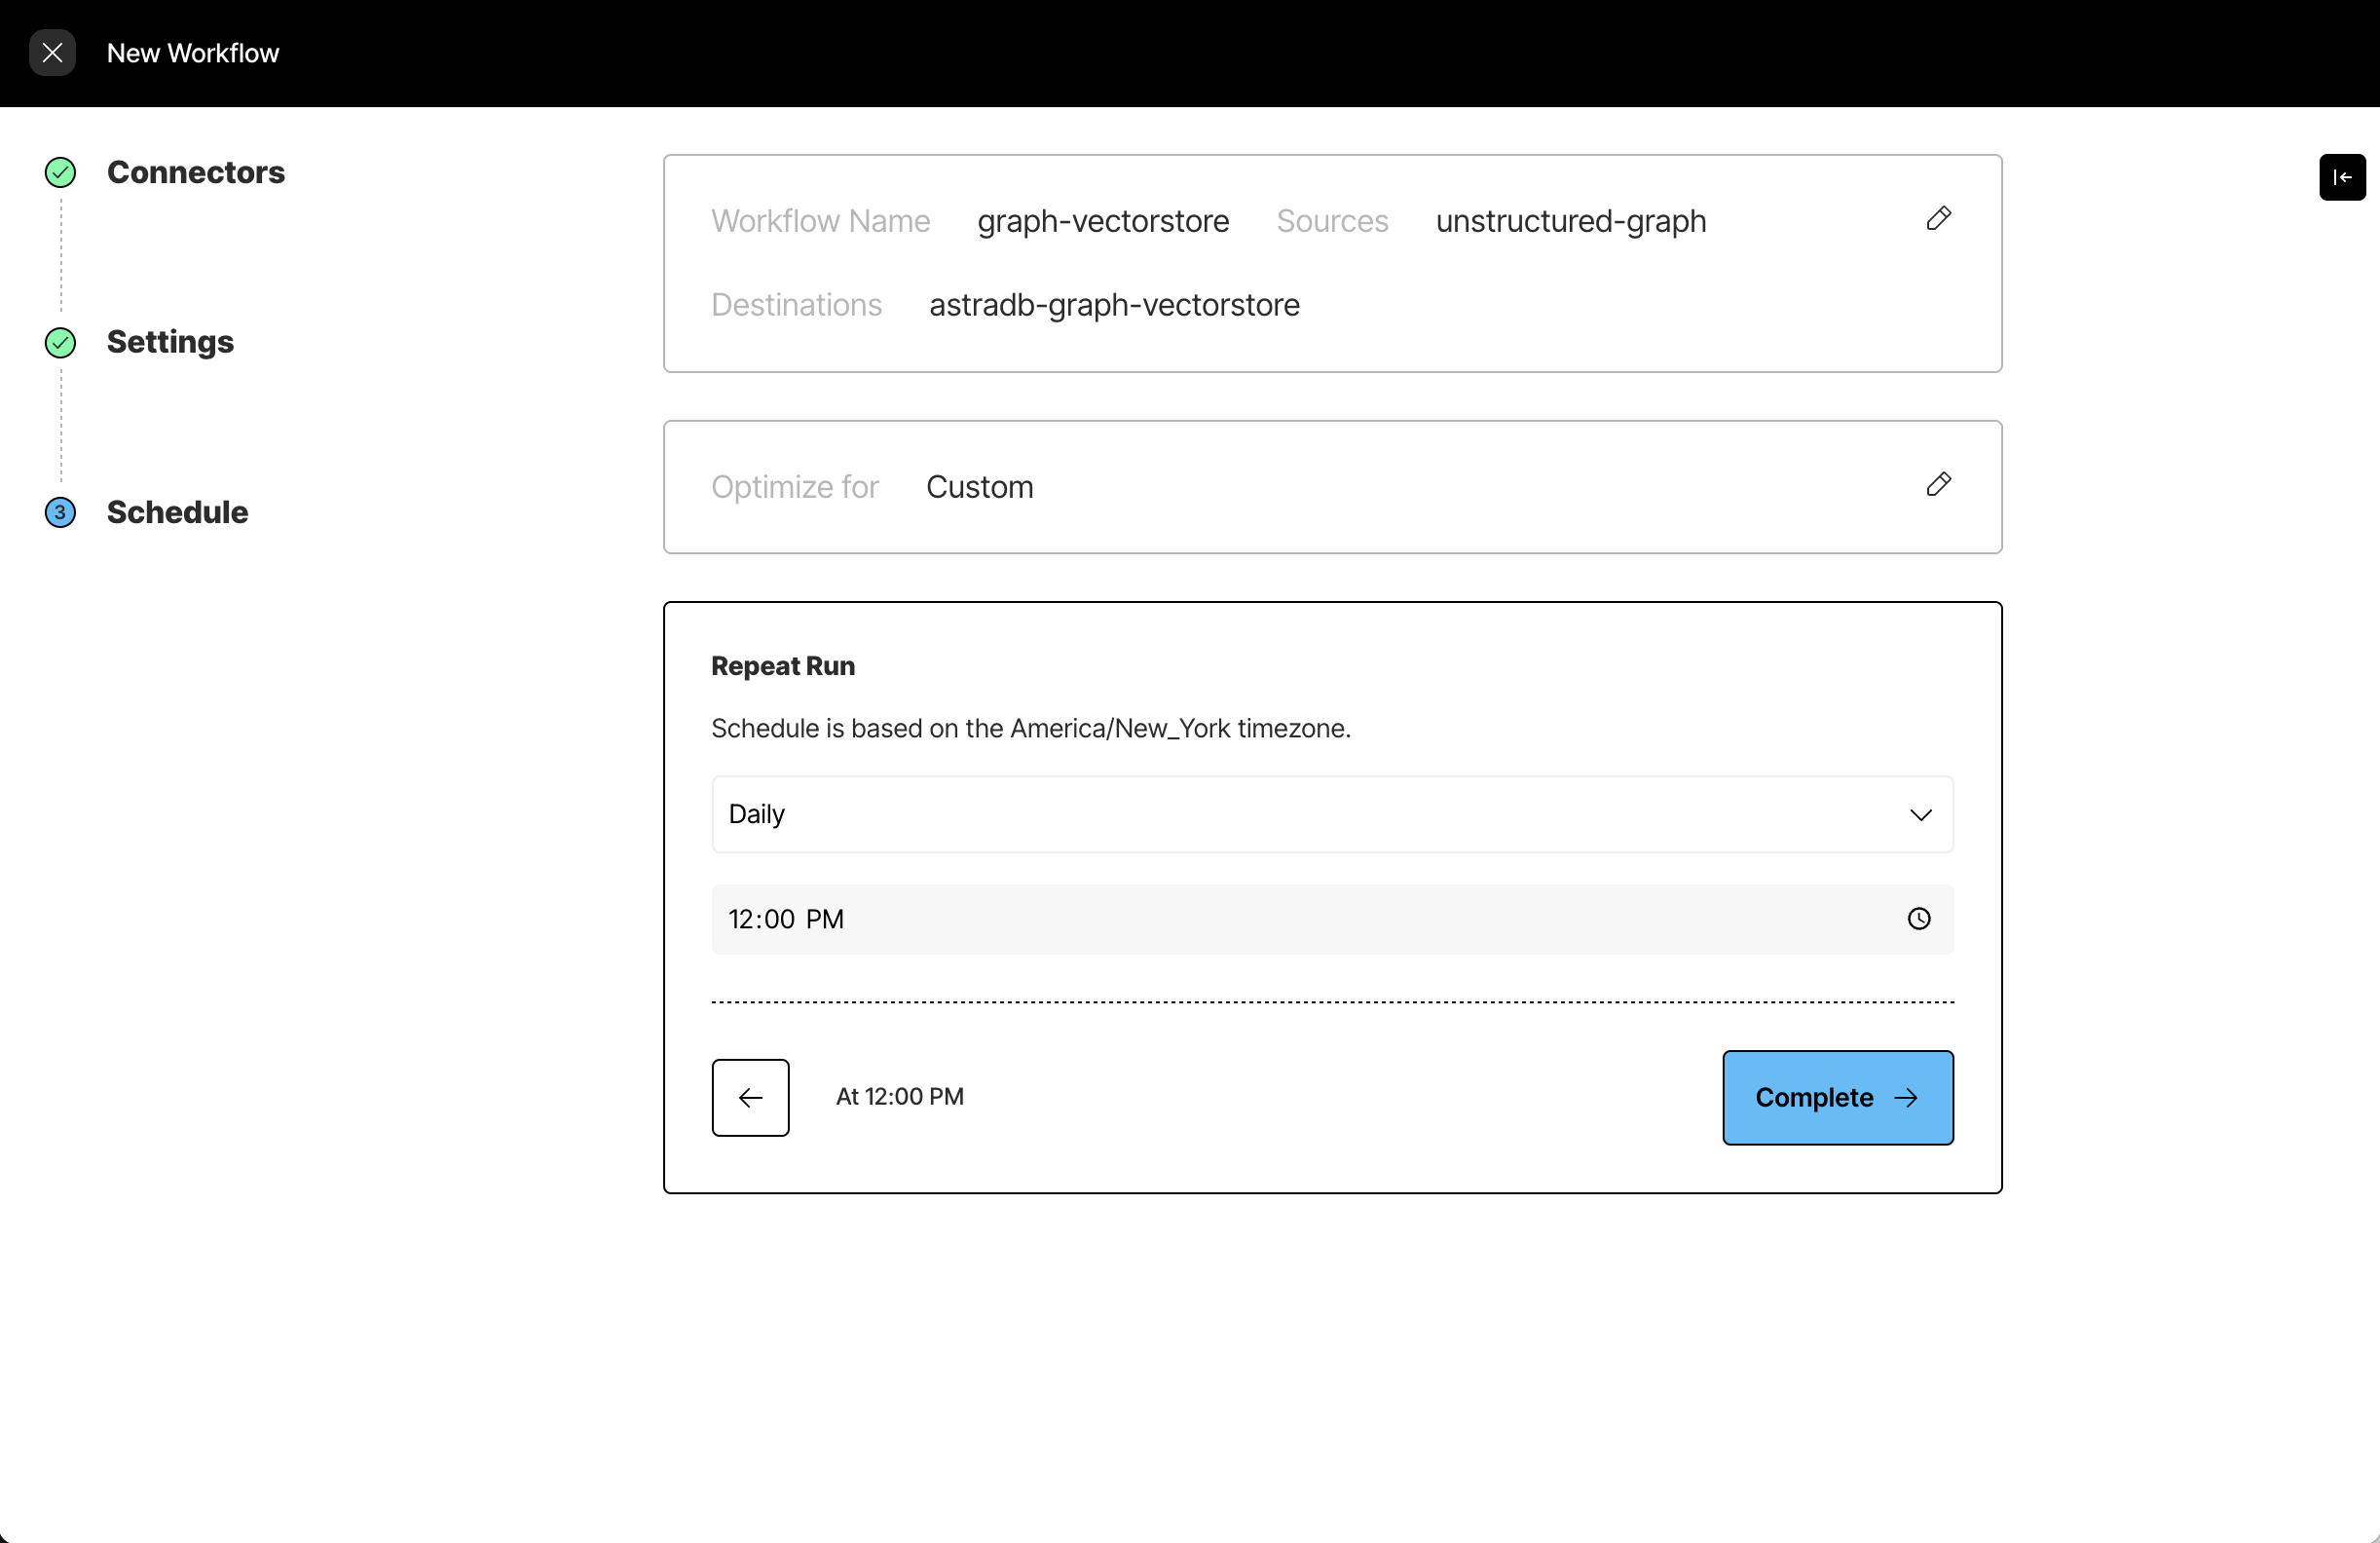

Execute your pipeline to load your documents into your AstraDB collection.

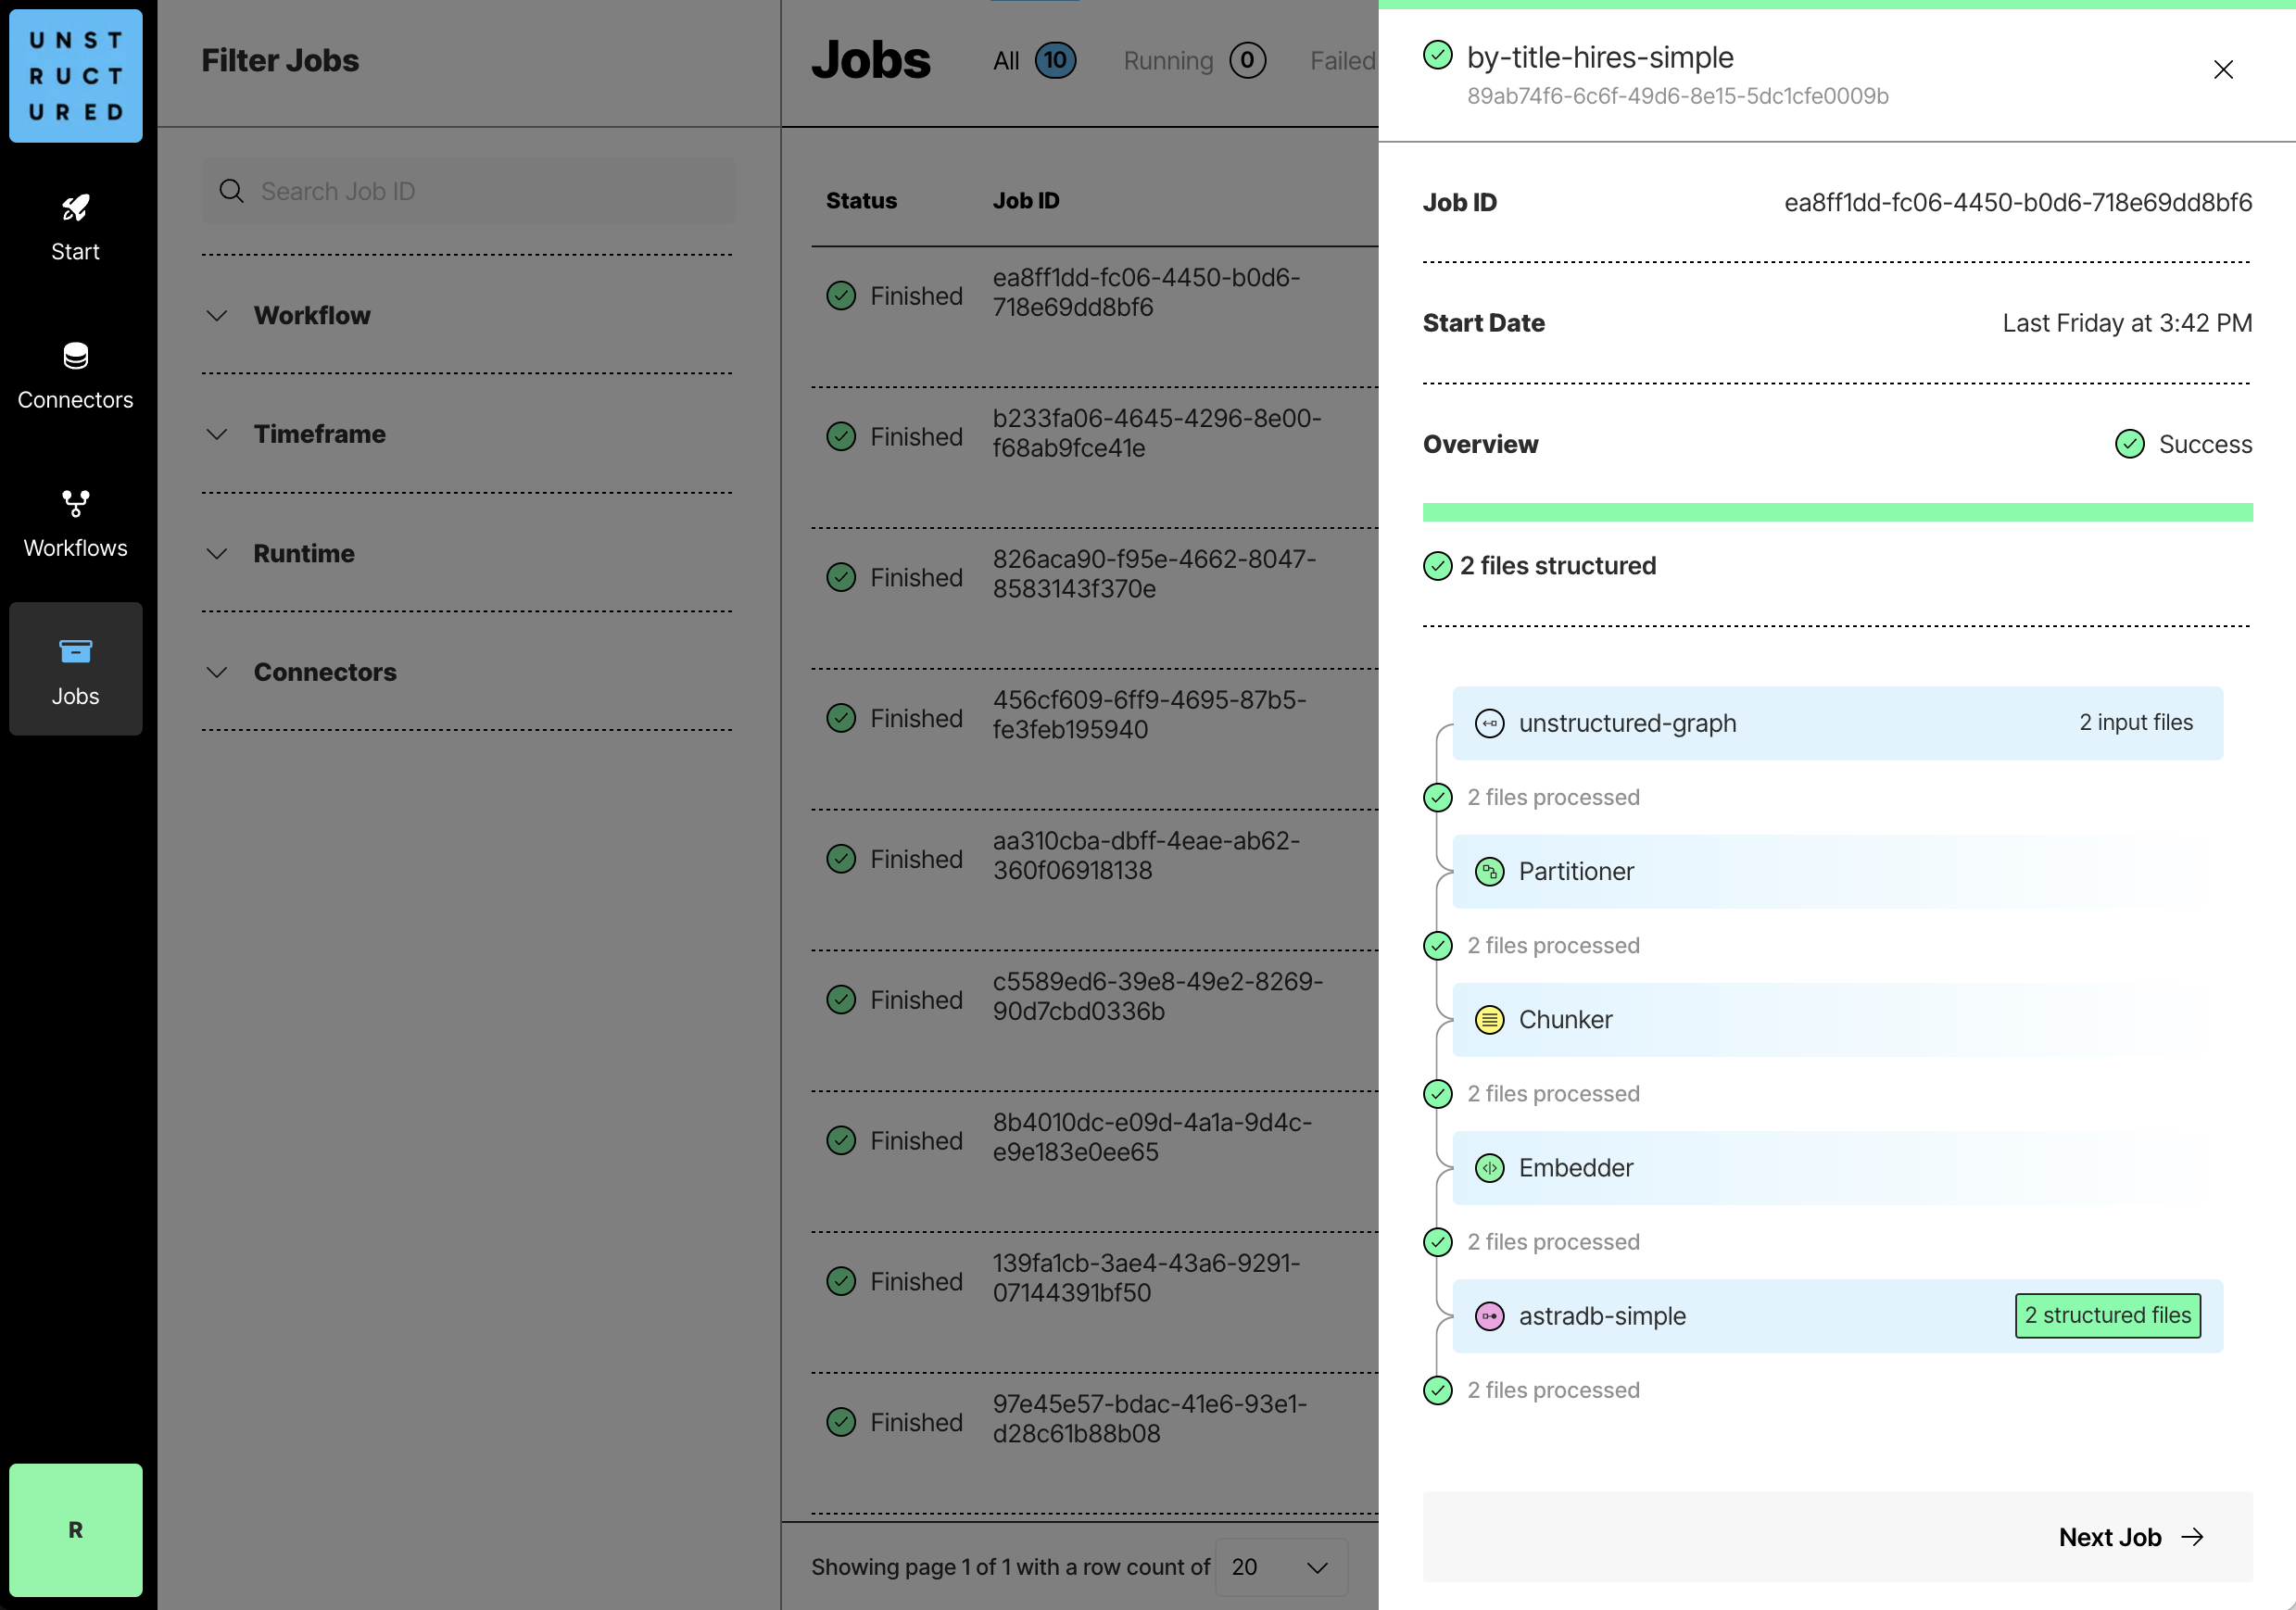

## (Alternative) Loading documents into AstraDB with OSS Unstructured

The opensource unstructured library can also be used to parse documents.

In [ ]:
%pip install langchain_astradb langchain_openai langchain_community pyvis unstructured[pdf]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.5/409.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 19

In [ ]:
from getpass import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass("Open AI API Key")

Open AI API Key··········


In [ ]:
os.environ["ASTRA_DB_APPLICATION_TOKEN"] = getpass("Astra DB Application Token")
os.environ["ASTRA_DB_API_ENDPOINT"] = getpass("Astra DB API Endpoint")

Astra DB Application Token··········
Astra DB API Endpoint··········


In [ ]:
from langchain_astradb import AstraDBGraphVectorStore
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(model="text-embedding-3-large")

vectorstore = AstraDBGraphVectorStore(
  collection_name="simple",
  embedding=embedding,
)

<ipython-input-6-d4feb97cd464>:6: LangChainBetaWarning: The class `AstraDBGraphVectorStore` is in beta. It is actively being worked on, so the API may change.
  vectorstore = AstraDBGraphVectorStore(
/usr/local/lib/python3.10/dist-packages/langchain_astradb/utils/astradb.py:388: UserWarning: Astra DB collection 'simple' is detected as having indexing turned on for all fields (either created manually or by older versions of this plugin). This implies stricter limitations on the amount of text each string in a document can store. Consider indexing anew on a fresh collection to be able to store longer texts. See https://github.com/langchain-ai/langchain-datastax/blob/main/libs/astradb/README.md#warnings-about-indexing for more details.
  if not self._validate_indexing_policy(


In [ ]:
import os
import requests

# List of URLs to download
urls = [
    "https://arxiv.org/pdf/2404.16130"
]

# Directory to save the files
save_dir = "./content/sample_data/"

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

# Function to download a file
def download_file(url, save_path):
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as file:
            file.write(response.content)
        print(f"Downloaded: {save_path}")
    else:
        print(f"Failed to download: {url}")

# Loop through the URLs and download each file
for url in urls:
    file_name = url.split("/")[-1]
    save_path = os.path.join(save_dir, file_name)
    download_file(url, save_path)

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from unstructured.partition.auto import partition
from langchain_core.documents.base import Document

import os
import glob

# Use glob to find all PDF files in the directory
pdf_files = glob.glob(os.path.join(save_dir, "*"))
docs = []

for pdf_file in pdf_files:
    elements = partition(filename=pdf_file)
    for element in elements:
      metadata = element.metadata.to_dict()
      metadata["element_id"] = element.id
      if "links" in metadata:
        metadata["unstructured_links"] = metadata.pop("links")
      docs.append(Document(
        id=element.id,
        metadata=metadata,
        page_content=element.text,
      ))

vectorstore.add_documents(docs)

Downloaded: ./content/sample_data/2404.16130


['b8b36fbfe305151871a630b86e87a6b7',
 '28cbe5b25cc8a73443e8a4d7a5f69f61',
 '133d90bb1b72ff808903e21ee6f0a307',
 'dc67d64da174dd612b4348ec40c3b023',
 '169953bdbd1cabcdfbd40a5dbfc4aa0b',
 '0beef52ad9aa6c860e410d54f32cf942',
 '612de5a88d1f6c757c992f6c23b70cbc',
 'bac4166327ac949ff633c76394da6c75',
 '1ff3404461a3df7f062bd5ec3ab5ba99',
 'f2d1c1d50543f6f101a05540068f9d21',
 '63298b1e8e94e4307d9f2064580666b6',
 'dfe0f18dd30323580604e8f0f5fb5228',
 '237dcff40437451e738b1386e917feef',
 'e8396e1667e43ee24e66a1eab2f94bed',
 '806f60aa6880ae820111ca36ac1844ef',
 'b19126555b39be5a93d44d7c4cea6f8a',
 'cee451ae973d8aacb3b3d4df547314b9',
 '5c1c3d259dc195fa0df02e358e52e7e8',
 'd3979792e86f8c04a712c6ccf1e608e3',
 '30761144158826bcda86bb8ed3a8440d',
 'add96800a602aeccadb2daf8fc35af6e',
 'd713c227e495b73639a6fb2dcb3915bc',
 '539f430b6b6e5a908ec4e1b8342fd15b',
 'e7a101c1cfa1366a513389f1169eba75',
 '96e34dd39d23cdc8a5f785eb74bb4f89',
 'c0c18778dd10f5b7d9879af9fc3a3c53',
 '723c2408c535c13051f03cafefa3871d',
 

In [ ]:
len(docs)

383

## Adding Graph edges to the AstraDB Graph Vectorstore

Semantic embeddings are powerful, but they can miss some connections, for example the hierarchical structure of your documents.

Fortunately, Unstructured captures this information and includes it as row-level metadata. Let's write a quick script to add a graph overlay on top of the documents created by Unstructured.

This script creates a graph edge connecting documents to their parents by identifying matches between `element_id` and `parent_id`.

In [ ]:
import base64
import zlib
import json

from langchain_community.graph_vectorstores.links import Link, add_links, get_links

while True:
  to_extend = vectorstore.metadata_search(filter={"graph_edges": {"$exists": False}}, n=1000)
  if len(to_extend) == 0 :
    break

  upgraded_metadata: dict[str, dict] = {}

  for doc in to_extend:
    element_ids = set()
    parent_ids = set()

    # Incoming edge from the element ID generated by Unstructured
    element_ids.add(doc.metadata["element_id"])

    if "parent_id" in doc.metadata:
      # Outgoing edge to the parent ID generated by Unstructured
      parent_ids.add(doc.metadata["parent_id"])

    if "metadata" in doc.metadata and "orig_elements" in doc.metadata["metadata"]:
      # Extract Unstructured elements nested in composite elements
      decoded_b64_bytes = base64.b64decode(doc.metadata["metadata"]["orig_elements"])
      elements_json_bytes = zlib.decompress(decoded_b64_bytes)
      elements_json_str = elements_json_bytes.decode("utf-8")
      element_dicts = json.loads(elements_json_str)

      for original_element in element_dicts:
        # Incoming edge from the nested element's ID
        element_ids.add(original_element["element_id"])

        if "parent_id" in original_element["metadata"]:
          # Outgoing edge to the neste element's parent ID
          parent_ids.add(original_element["metadata"]["parent_id"])

    # Add all the hierarchical edges extracted by unstructured to the document
    add_links(doc, [Link.bidir(kind="sections", tag=id) for id in element_ids])
    add_links(doc, [Link.bidir(kind="sections", tag=id) for id in parent_ids])

    doc.metadata.update(graph_edges=True)

  # Update the documents to include graph edges
  vectorstore.add_documents(to_extend)

### TODO: Visualize query graphs

(under construction - goal is to show the differences between naive vector search and graph vector search by visualizing the graphs formed by search results)

In [ ]:
from pyvis.network import Network
from IPython.display import HTML
from langchain_community.graph_vectorstores.networkx import documents_to_networkx

def visualize(docs, file_name="graph"):
        net = Network(
            notebook=True,
            cdn_resources="in_line",
            bgcolor="#222222",
            font_color="white",
            height="750px",
            width="100%",
        )
        # Convert the NetworkX graph to a PyVis graph
        G = documents_to_networkx(docs, tag_nodes=False)

        net.from_nx(G)

        # Render the graph in the Jupyter notebook
        net.show(file_name + ".html")
        return HTML(filename=file_name + ".html")

The document structure can be visualized as a graph, showing the hierarchical relationships extracted from the document by Unstructured. Clusters represent sections within the document.

In [ ]:
all = vectorstore.metadata_search(n=1000)
visualize(all)

graph.html


Traditional vector search (aka traversal search with depth zero) returns documents based exclusively on semantic similarity. Graphically, we can see that these documents aren't connected to each other, indicating they come from different sections of the document. The four nodes represent the four documents closest to our query in semantic space.

In [ ]:
vector_results = list(vectorstore.traversal_search(
    "What are the differences between Graph RAG and naive RAG",
    k=4,
    depth=0,
))
visualize(vector_results)

graph.html


Increasing the traversal depth retrieves the "neighborhood" around each document, providing additional context for the model. In the graphical representation we can see that several documents are now part of larger clusters, formed by incorporating non-semantic relationships between documents (in this case, the document's hierarchical structure).

In [ ]:
traversal_results = list(vectorstore.traversal_search(
    "What are the differences between Graph RAG and naive RAG",
    k=4,
    depth=2,
))
visualize(traversal_results)

graph.html


"MMR Traversal" is a retrieval strategy that includes document rescoring. This strategy traverses the graph as before, but selects a subgraph, balancing similarity (documents close to the search vector) and diversity (documents far away from each other). In the graphical representation you can see there are exactly four documents and some are connected with edges (suggesting they were discovered through traversal). This type of traversal provides a way to incorporate both graph and vector similarity in a single query.

In [ ]:
mmr_traversal_results = list(vectorstore.mmr_traversal_search(
    "What are the differences between Graph RAG and naive RAG",
    k=4,
    depth=2,
))
visualize(mmr_traversal_results)

graph.html


## Query the hybrid graph + vector store in your RAG app

Now that your DB includes graph metadata, you can use LangChain's hybrid graph + vector retrievers.


In [ ]:
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough

llm = ChatOpenAI(temperature=1, model_name="gpt-4-turbo-2024-04-09")

prompt = ChatPromptTemplate.from_template("""
You are an specialist in artificial intelligence. Your role is to answer questions accurately based on the provided context. If the context does not contain enough information, respond by stating that the context doesn't allow you to answer the question.
Here is the context: {context}
Based on the context above, answer this question: {question}""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

retriever = vectorstore.as_retriever(
    search_type = "traversal",  # <-- Combines graph traversal with vector retrieval
    search_kwargs = {
        "k": 5,
        "depth": 2,
    },
)

chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
)

resp = chain.invoke(
    "How does Graph RAG work?"
)
print(resp.content)

Graph RAG (Retrieval-Augmented Generation) is an approach that integrates knowledge graph generation, retrieval-augmented generation, and query-focused summarization (QFS) to enhance the process of sensemaking over large text corpora. It operates on a global scale, aiming to provide improved comprehensiveness and diversity of answers compared to a naive baseline, as well as offering competitive performance against other global methods while conserving computational resources.

The process begins by generating a knowledge graph from the textual data, which structures the information in a way that is conducive to efficient querying and retrieval. This graph serves as the foundation for the retrieval component, allowing the system to fetch relevant information quickly in response to user queries. The retrieved information then undergoes a summarization process focused on the query's specifics, aiming to provide concise, relevant answers derived from a broader context within the graph.

Th